Fichier 2019 chargé avec succès !
Colonnes disponibles : ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


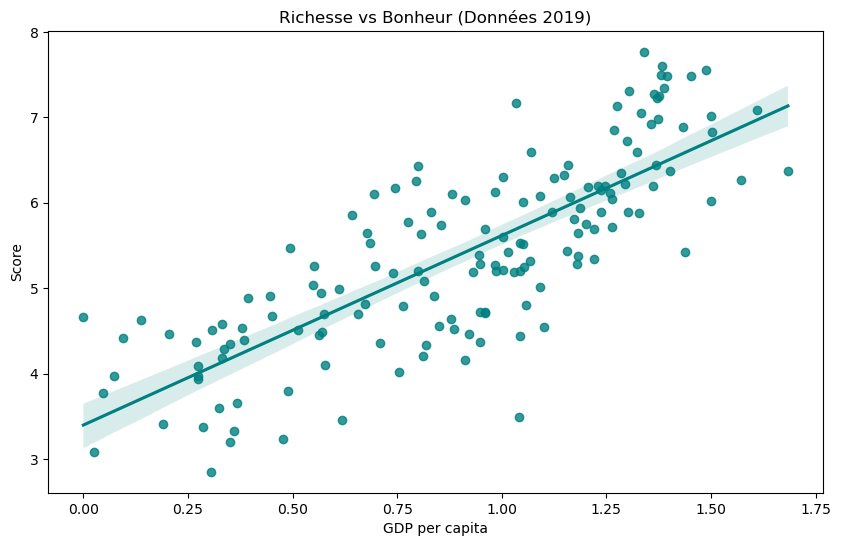

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# 1. Chargement DIRECT 
df = pd.read_csv('2019.csv')

# 2. On affiche pour fêter ça !
print("Fichier 2019 chargé avec succès !")
print("Colonnes disponibles :", df.columns.tolist())
display(df.head())

# 3. Le graphique de corrélation
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='GDP per capita', y='Score', color='teal')
plt.title('Richesse vs Bonheur (Données 2019)')
plt.show()


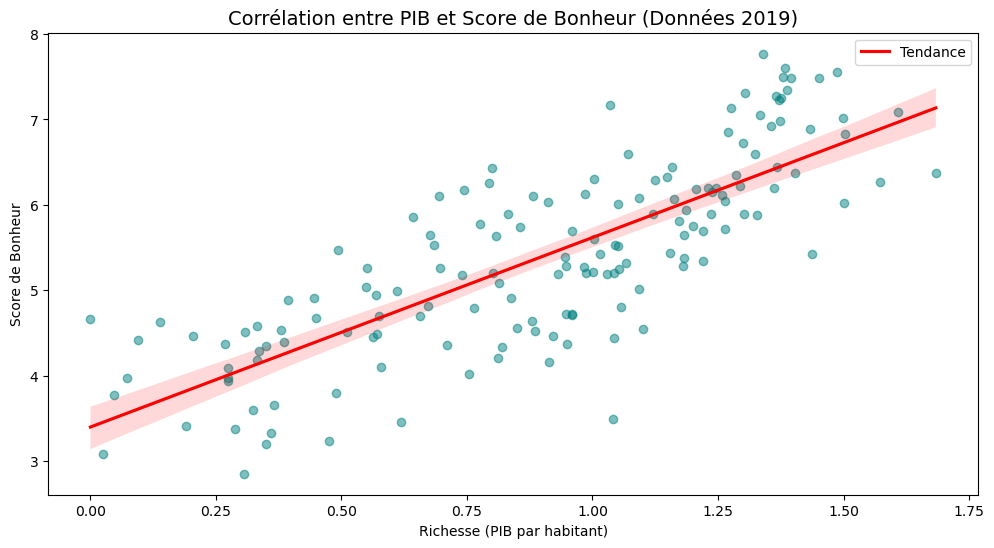

In [22]:
plt.figure(figsize=(12, 6))

# Nuage de points avec les noms de colonnes EXACTS de 2019
sns.regplot(data=df, x='GDP per capita', y='Score', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Tendance'})

plt.title('Corrélation entre PIB et Score de Bonheur (Données 2019)', fontsize=14)
plt.xlabel('Richesse (PIB par habitant)')
plt.ylabel('Score de Bonheur')
plt.legend()
plt.show()



In [24]:
# 1. On calcule les moyennes avec les colonnes de 2019
mean_score = df['Score'].mean()
mean_gdp = df['GDP per capita'].mean()

# 2. Pays "Sages" : PIB < moyenne mais Bonheur > moyenne + 0.5
outliers_happy = df[(df['GDP per capita'] < mean_gdp) & (df['Score'] > mean_score + 0.5)]

# 3. Pays "Riches mais Tristes" : PIB > moyenne + 0.3 mais Bonheur < moyenne
outliers_unhappy = df[(df['GDP per capita'] > mean_gdp + 0.3) & (df['Score'] < mean_score)]

print("--- Pays Exceptionnellement Heureux (Malgré un PIB plus bas) ---")
# On utilise 'Country or region' au lieu de 'Country name'
print(outliers_happy[['Country or region', 'Score', 'GDP per capita']].head())

print("\n--- Pays Riches avec un Bonheur Inattendu (Plus bas que prévu) ---")
print(outliers_unhappy[['Country or region', 'Score', 'GDP per capita']].head())



--- Pays Exceptionnellement Heureux (Malgré un PIB plus bas) ---
   Country or region  Score  GDP per capita
26         Guatemala  6.436           0.800
34       El Salvador  6.253           0.794
40        Uzbekistan  6.174           0.745
44         Nicaragua  6.105           0.694
45            Kosovo  6.100           0.882

--- Pays Riches avec un Bonheur Inattendu (Plus bas que prévu) ---
   Country or region  Score  GDP per capita
79          Malaysia  5.339           1.221


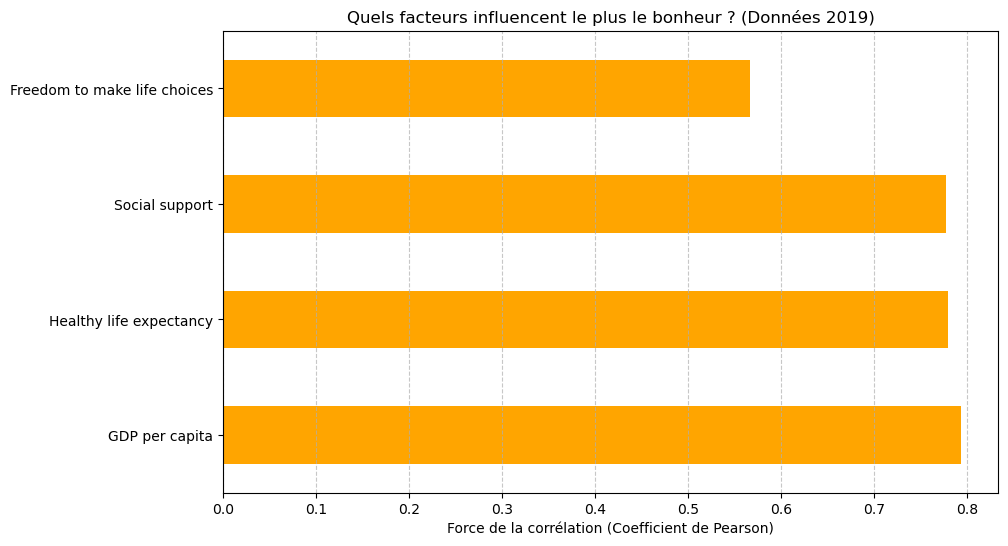

In [25]:
# 1. Adapter les noms des facteurs pour le fichier 2019
factors_2019 = ['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices']

# 2. Calculer les corrélations avec la colonne 'Score'
correlations = df[factors_2019 + ['Score']].corr()['Score'].sort_values(ascending=False)

# 3. Générer le graphique
plt.figure(figsize=(10, 6))
# On retire 'Score' pour ne garder que les facteurs influents
correlations.drop('Score').plot(kind='barh', color='orange')

plt.title('Quels facteurs influencent le plus le bonheur ? (Données 2019)')
plt.xlabel('Force de la corrélation (Coefficient de Pearson)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
